In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber

In [2]:
def plot_predictions(test, predicted):
    plt.plot(test, color='red', label='Real IBM Stock Price')
    plt.plot(predicted, color='blue', label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("-" * 30)
    print("Błąd średniokwadratowy modelu: {:.2f}.".format(rmse))
    print("-" * 30)

def return_mae(test, predicted):
    mae = mean_absolute_error(test, predicted)
    mape = mean_absolute_percentage_error(test, predicted) * 100
    print("Średni błąd bezwzględny: {:.2f}.".format(mae))
    print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
    print("-" * 30)

In [3]:
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [4]:
training_set = dataset[:'2016'].iloc[:, 1:2].values
test_set = dataset['2017':].iloc[:, 1:2].values

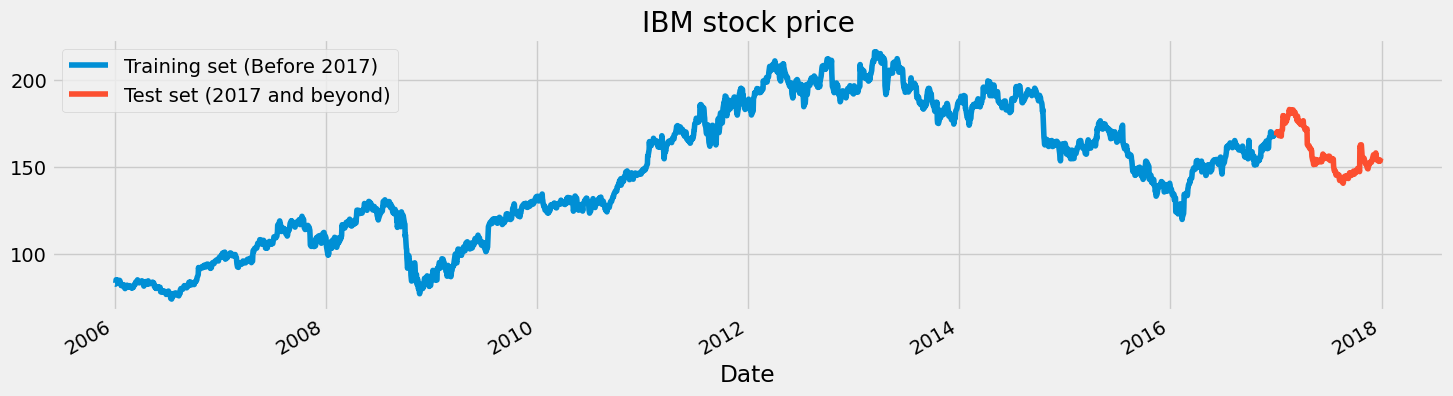

In [5]:
dataset["High"][:'2016'].plot(figsize=(16,4), legend=True)
dataset["High"]['2017':].plot(figsize=(16,4), legend=True)
plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [6]:
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

In [7]:
X_train = []
y_train = []
for i in range(60, 2769):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [8]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [9]:
regressor = Sequential()
regressor.add(Input(shape=(X_train.shape[1], 1)))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop', loss='mean_squared_error')

regressor.fit(X_train, y_train, epochs=50, batch_size=32)


Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0233
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0102
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0082
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0072
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0060
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0056
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0053
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0045
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0046
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0042
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0040
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0039
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0033
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0034
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0032
Epoc

In [10]:
dataset_total = pd.concat((dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

In [11]:
X_test = []
for i in range(60, 311):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


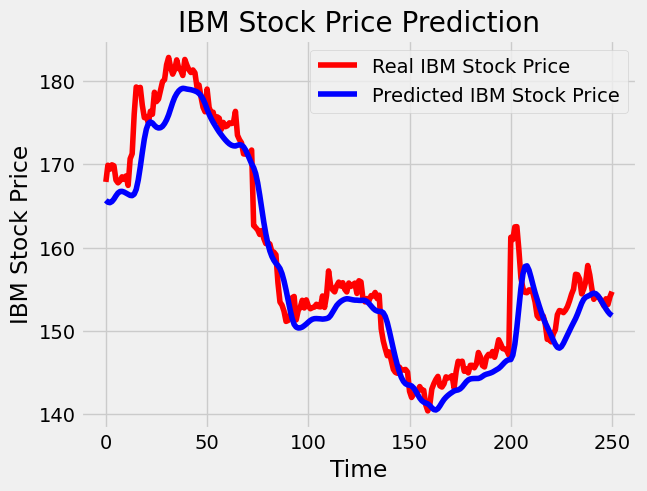

In [12]:
plot_predictions(test_set, predicted_stock_price)

In [13]:
return_rmse(test_set, predicted_stock_price)
return_mae(test_set, predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu: 3.36.
------------------------------
Średni błąd bezwzględny: 2.47.
Średni błąd bezwzględny procentowy: 1.54%
------------------------------


-----------------------Alternatywa--------------------------

In [14]:
regressorGRU = Sequential()

regressorGRU.add(Input(shape=(X_train.shape[1], 1)))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(Dense(units=1))

regressorGRU.compile(optimizer='rmsprop', loss='mean_squared_error')

early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
regressorGRU.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0190
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0087
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0072
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0064
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0054
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0047
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0044
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0041
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0037
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0036
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0036
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0034
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0033
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0032
Epoch 15/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - lo

In [15]:
X_test = []
for i in range(60, 311):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


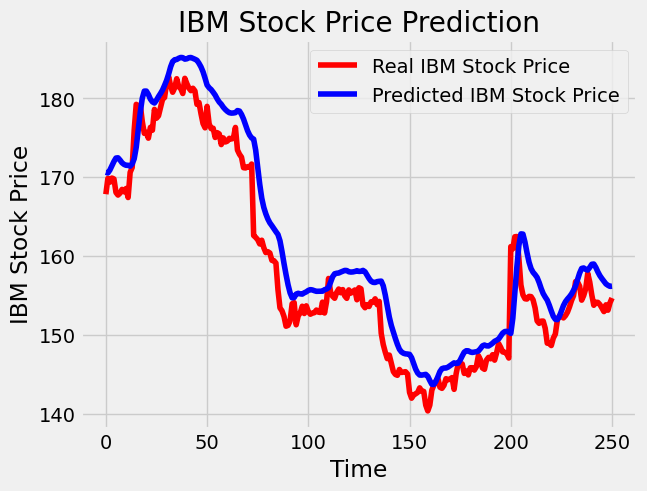

In [16]:
plot_predictions(test_set, GRU_predicted_stock_price)

In [17]:
return_rmse(test_set, GRU_predicted_stock_price)
return_mae(test_set, GRU_predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu: 3.90.
------------------------------
Średni błąd bezwzględny: 3.35.
Średni błąd bezwzględny procentowy: 2.11%
------------------------------


---------------------Zadanie--------------


In [20]:
training_set_close = dataset[:'2016']['Close'].values.reshape(-1, 1)
test_set_close = dataset['2017':]['Close'].values.reshape(-1, 1)

sc_close = MinMaxScaler(feature_range=(0, 1))
training_set_scaled_close = sc_close.fit_transform(training_set_close)

X_train_close = []
y_train_close = []
for i in range(60, len(training_set_scaled_close)):
    X_train_close.append(training_set_scaled_close[i-60:i, 0])
    y_train_close.append(training_set_scaled_close[i, 0])

X_train_close, y_train_close = np.array(X_train_close), np.array(y_train_close)
X_train_close = np.reshape(X_train_close, (X_train_close.shape[0], X_train_close.shape[1], 1))

dataset_total_close = dataset['Close']
inputs_close = dataset_total_close[len(dataset_total_close) - len(test_set_close) - 60:].values.reshape(-1, 1)
inputs_close = sc_close.transform(inputs_close)

X_test_close = []
for i in range(60, len(inputs_close)):
    X_test_close.append(inputs_close[i-60:i, 0])

X_test_close = np.array(X_test_close)
X_test_close = np.reshape(X_test_close, (X_test_close.shape[0], X_test_close.shape[1], 1))


In [21]:
from keras.optimizers import Adam, SGD, RMSprop
from keras.losses import Huber, MeanAbsoluteError, LogCosh, MeanSquaredError

ILOSC_JEDNOSTEK = 100
OPTYMALIZATOR = Adam()
FUNKCJA_STRATY = Huber()
EPOKI = 100

print(f"Trenowanie modelu: Jednostki={ILOSC_JEDNOSTEK}, Optymalizator={OPTYMALIZATOR.name}, Straty={FUNKCJA_STRATY.name}")

model_eksperyment = Sequential()
model_eksperyment.add(Input(shape=(X_train_close.shape[1], 1)))

model_eksperyment.add(LSTM(units=ILOSC_JEDNOSTEK, return_sequences=True))
model_eksperyment.add(Dropout(0.2))

model_eksperyment.add(LSTM(units=ILOSC_JEDNOSTEK, return_sequences=True))
model_eksperyment.add(Dropout(0.2))

model_eksperyment.add(LSTM(units=ILOSC_JEDNOSTEK, return_sequences=True))
model_eksperyment.add(Dropout(0.2))

model_eksperyment.add(LSTM(units=ILOSC_JEDNOSTEK))
model_eksperyment.add(Dropout(0.2))

model_eksperyment.add(Dense(units=1))

model_eksperyment.compile(optimizer=OPTYMALIZATOR, loss=FUNKCJA_STRATY)

early_stop_eksperyment = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_eksperyment.fit(
    X_train_close,
    y_train_close,
    epochs=EPOKI,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_eksperyment]
)

Trenowanie modelu: Jednostki=100, Optymalizator=adam, Straty=huber_loss
Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0083 - val_loss: 8.2350e-04
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0020 - val_loss: 8.3100e-04
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0022 - val_loss: 7.2039e-04
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0015 - val_loss: 6.1694e-04
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0015 - val_loss: 5.8161e-04
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0014 - val_loss: 5.3761e-04
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0014 - val_loss: 0.0019
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014 - val_loss: 6.7379e-04
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - val_loss: 4.8735e-04
Epoch 10/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - val_loss: 4.6242e-04
Epoch 11/100
77/77 ━━━━━━━━━━━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


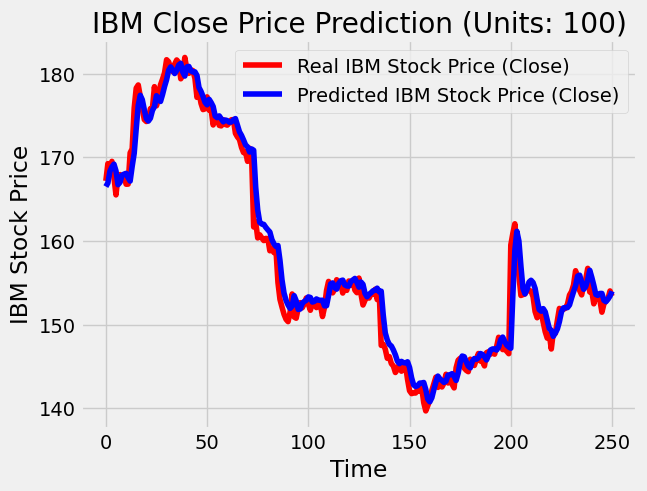

------------------------------
Błąd średniokwadratowy modelu: 1.89.
------------------------------
Średni błąd bezwzględny: 1.28.
Średni błąd bezwzględny procentowy: 0.81%
------------------------------
Model zatrzymał się po 87 epokach.


In [22]:
predicted_close_price = model_eksperyment.predict(X_test_close)
predicted_close_price = sc_close.inverse_transform(predicted_close_price)

plt.plot(test_set_close, color='red', label='Real IBM Stock Price (Close)')
plt.plot(predicted_close_price, color='blue', label='Predicted IBM Stock Price (Close)')
plt.title(f'IBM Close Price Prediction (Units: {ILOSC_JEDNOSTEK})')
plt.xlabel('Time')
plt.ylabel('IBM Stock Price')
plt.legend()
plt.show()

return_rmse(test_set_close, predicted_close_price)
return_mae(test_set_close, predicted_close_price)

wykonane_epoki = len(history.history['loss'])
print(f"Model zatrzymał się po {wykonane_epoki} epokach.")